# GPSite Reproducible Example Workflow

This notebook shows the GPSite normalization and thresholding workflow step by step using an example input table.

## 1. Import packages

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path
from scipy import stats
from sklearn.preprocessing import QuantileTransformer

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style='ticks')

## 2. Set input and parameters

In [2]:
INPUT_FILE = Path('GPSite_data_example.csv')
OUTPUT_PREFIX = 'gpsite_reproducible_example'

BINDING_COLS = [
    'DNA_binding',
    'RNA_binding',
    'Peptide_binding',
    'Protein_binding',
    'ATP_binding',
    'ZN_binding',
    'CA_binding',
    'MG_binding',
    'MN_binding',
]

P_THRESHOLD = 0.05
Z_THRESHOLD = stats.norm.ppf(1 - P_THRESHOLD / 2)

print('Input file:', INPUT_FILE)
print('Nominal P threshold:', P_THRESHOLD)
print('Two-sided Z threshold:', round(Z_THRESHOLD, 4))

Input file: GPSite_data_example.csv
Nominal P threshold: 0.05
Two-sided Z threshold: 1.96


## 3. Load example GPSite output

In [3]:
df = pd.read_csv(INPUT_FILE)
print('Shape:', df.shape)
df.head()

Shape: (197, 35)


,Mut_Sample,Transcript,mut_info,path,AA,DNA_binding,RNA_binding,Peptide_binding,Protein_binding,ATP_binding,...,DNA_binding_diff,RNA_binding_diff,Peptide_binding_diff,Protein_binding_diff,ATP_binding_diff,HEM_binding_diff,ZN_binding_diff,CA_binding_diff,MG_binding_diff,MN_binding_diff
0,EMS4-0eb016,Zm00001d002349_T001,E575K,A0A1D6DZU6,K,0.000,0.000,0.001,0.018,0.000,...,0.000,0.000,0.000,0.017,0.000,0.000,0.000,0.001,0.001,0.000
1,EMS4-1751ca,Zm00001d031871_T001,P118L,A0A1D6KLY8,L,0.017,0.119,0.001,0.087,0.000,...,0.001,0.000,0.000,0.005,0.000,0.000,0.000,0.000,0.000,0.000
2,EMS4-23a69f,Zm00001d031871_T001,T143I,A0A1D6KLY8,I,0.000,0.000,0.002,0.027,0.000,...,0.000,0.000,0.002,0.016,0.000,0.002,0.000,0.000,0.000,0.000
3,EMS4-012875,Zm00001d031871_T001,A985T,A0A1D6KLY8,T,0.001,0.001,0.011,0.217,0.000,...,0.000,0.000,0.005,0.013,0.000,0.001,0.000,0.000,0.000,0.000
4,EMS4-01287c,Zm00001d031871_T001,R783C,A0A1D6KLY8,C,0.170,0.230,0.009,0.383,0.007,...,0.100,0.029,0.006,0.023,0.003,0.015,0.012,0.001,0.001,0.003


## 4. Check required columns

In [4]:
required_cols = {'Mut_Sample', 'Transcript', 'mut_info', 'AA'}
required_cols.update(BINDING_COLS)
required_cols.update(f'{col}_WT' for col in BINDING_COLS)
missing = sorted(required_cols.difference(df.columns))

if missing:
    raise ValueError('Missing required columns: ' + ', '.join(missing))

print('All required columns are present.')

All required columns are present.


## 5. Recalculate `Δbinding` values

For each binding type, `Δbinding = mutant score - WT score`.

In [5]:
long_frames = []
diff_list = []

for binding_col in BINDING_COLS:
    mut_score = df[binding_col]
    wt_score = df[f'{binding_col}_WT']
    delta = mut_score - wt_score

    both_zero = (mut_score == 0) & (wt_score == 0)
    zero_delta = delta == 0
    keep = (~both_zero) & (~zero_delta)

    diff_list.append(delta[keep].to_numpy())

    long_frames.append(
        pd.DataFrame(
            {
                'Mut_Sample': df['Mut_Sample'],
                'Transcript': df['Transcript'],
                'mut_info': df['mut_info'],
                'AA': df['AA'],
                'binding_type': binding_col.replace('_binding', ''),
                'mut_score': mut_score,
                'wt_score': wt_score,
                'delta_binding': delta,
                'both_zero_filtered': both_zero,
                'zero_delta_filtered': zero_delta,
                'kept_for_statistics': keep,
            }
        )
    )

long_df = pd.concat(long_frames, ignore_index=True)
long_df.head()

,Mut_Sample,Transcript,mut_info,AA,binding_type,mut_score,wt_score,delta_binding,both_zero_filtered,zero_delta_filtered,kept_for_statistics
0,EMS4-0eb016,Zm00001d002349_T001,E575K,K,DNA,0.000,0.000,0.000,True,True,False
1,EMS4-1751ca,Zm00001d031871_T001,P118L,L,DNA,0.017,0.018,-0.001,False,False,True
2,EMS4-23a69f,Zm00001d031871_T001,T143I,I,DNA,0.000,0.000,0.000,True,True,False
3,EMS4-012875,Zm00001d031871_T001,A985T,T,DNA,0.001,0.001,0.000,False,True,False
4,EMS4-01287c,Zm00001d031871_T001,R783C,C,DNA,0.170,0.270,-0.100,False,False,True


## 6. Summarize filtering

Records are removed when mutant = WT = 0 or when `Δbinding = 0`.

In [6]:
filtered_df = long_df.loc[long_df['kept_for_statistics']].copy()
filter_summary = pd.Series(
    {
        'total_binding_records': int(len(long_df)),
        'filtered_both_zero': int(long_df['both_zero_filtered'].sum()),
        'filtered_zero_delta': int(long_df['zero_delta_filtered'].sum()),
        'retained_for_statistics': int(len(filtered_df)),
    }
)
filter_summary.to_frame(name='value')

,value
total_binding_records,1773
filtered_both_zero,763
filtered_zero_delta,1010
retained_for_statistics,763


## 7. Plot raw `Δbinding` distribution

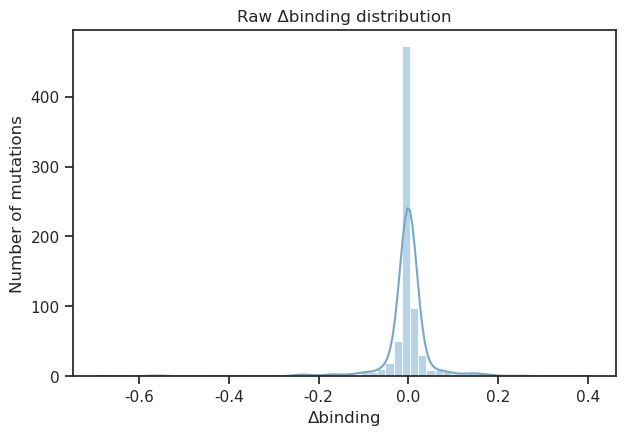

In [7]:
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.histplot(filtered_df['delta_binding'], bins=60, kde=True, ax=ax, color='#74a9cf', edgecolor=None)
ax.set_xlabel('Δbinding')
ax.set_ylabel('Number of mutations')
ax.set_title('Raw Δbinding distribution')
plt.show()

## 8. Quantile-normalize the filtered `Δbinding` values

In [8]:
flat_diff = np.concatenate(diff_list)
n_quantiles = min(10000, len(flat_diff))

qt = QuantileTransformer(
    output_distribution='normal',
    n_quantiles=n_quantiles,
    random_state=0,
)

z_scores = qt.fit_transform(flat_diff.reshape(-1, 1)).flatten()
filtered_df['z_score'] = z_scores
filtered_df['p_value'] = 2 * (1 - stats.norm.cdf(np.abs(z_scores)))

filtered_df[['delta_binding', 'z_score', 'p_value']].head()

,delta_binding,z_score,p_value
1,-0.001,0.036193,0.971129
4,-0.100,-1.773684,0.076115
7,0.030,1.413597,0.157480
9,0.001,0.257765,0.796588
13,0.020,1.253638,0.209974


## 9. Summarize normalized distribution

In [9]:
norm_summary = pd.Series(
    {
        'z_mean': float(np.mean(z_scores)),
        'z_std': float(np.std(z_scores)),
        'z_skewness': float(stats.skew(z_scores)),
        'z_kurtosis': float(stats.kurtosis(z_scores)),
    }
)
norm_summary.to_frame(name='value')

,value
z_mean,-0.000063
z_std,1.023673
z_skewness,0.000005
z_kurtosis,1.282827


## 10. Plot quantile-normalized Z-score distribution

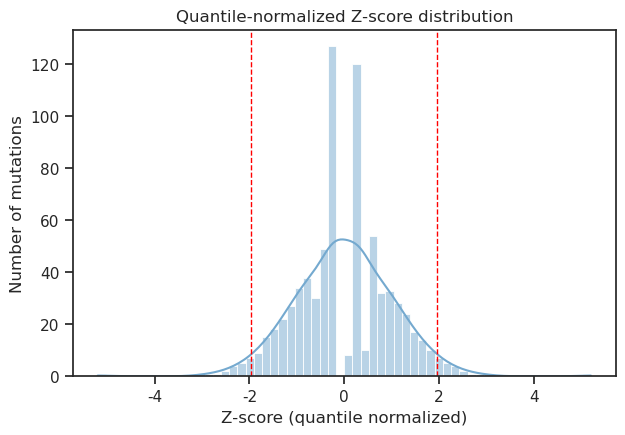

In [10]:
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.histplot(z_scores, bins=60, kde=True, ax=ax, color='#74a9cf', edgecolor=None)
ax.axvline(Z_THRESHOLD, color='red', linestyle='--', linewidth=1)
ax.axvline(-Z_THRESHOLD, color='red', linestyle='--', linewidth=1)
ax.set_xlabel('Z-score (quantile normalized)')
ax.set_ylabel('Number of mutations')
ax.set_title('Quantile-normalized Z-score distribution')
plt.show()

## 11. Derive the raw `Δbinding` threshold for `P < 0.05`

The nominal criterion is first defined in Z-space, then mapped back to the raw `Δbinding` scale.

In [11]:
delta_threshold = float(np.min(np.abs(filtered_df.loc[np.abs(filtered_df['z_score']) >= Z_THRESHOLD, 'delta_binding'])))
print('Two-sided Z threshold:', round(Z_THRESHOLD, 4))
print('Derived raw |Δbinding| threshold:', round(delta_threshold, 4))

Two-sided Z threshold: 1.96
Derived raw |Δbinding| threshold: 0.108


## 12. Apply nominal threshold filtering

In [12]:
filtered_df['pass_nominal_filter'] = (
    (filtered_df['delta_binding'].abs() >= delta_threshold)
    & (filtered_df['p_value'] < P_THRESHOLD)
)

hit_summary = pd.Series(
    {
        'n_p_lt_0_05': int(np.sum(filtered_df['p_value'] < P_THRESHOLD)),
        'n_abs_delta_ge_threshold': int(np.sum(filtered_df['delta_binding'].abs() >= delta_threshold)),
        'n_pass_both_filters': int(np.sum(filtered_df['pass_nominal_filter'])),
    }
)
hit_summary.to_frame(name='value')

,value
n_p_lt_0_05,40
n_abs_delta_ge_threshold,43
n_pass_both_filters,40


## 13. Inspect example hits

In [13]:
filtered_df.loc[filtered_df['pass_nominal_filter']].head(10)

,Mut_Sample,Transcript,mut_info,AA,binding_type,mut_score,wt_score,delta_binding,both_zero_filtered,zero_delta_filtered,kept_for_statistics,z_score,p_value,pass_nominal_filter
41,EMS4-0eb02c,Zm00001d002349_T001,E201K,K,DNA,0.133,0.025,0.108,False,False,True,1.961088,4.986877e-02,True
59,EMS4-30082e,Zm00001d002349_T001,E158K,K,DNA,0.228,0.040,0.188,False,False,True,2.558957,1.049869e-02,True
89,EMS4-23a68f,Zm00001d031871_T001,E1112K,K,DNA,0.618,0.363,0.255,False,False,True,3.008585,2.624672e-03,True
183,EMS4-016d06,Zm00001d032961_T003,R529C,C,DNA,0.042,0.285,-0.243,False,False,True,-2.414703,1.574803e-02,True
185,EMS4-016cfd,Zm00001d032961_T003,P274S,S,DNA,0.026,0.202,-0.176,False,False,True,-2.118642,3.412073e-02,True
186,EMS4-016ce8,Zm00001d032961_T003,R34C,C,DNA,0.037,0.729,-0.692,False,False,True,-5.199338,2.000000e-07,True
194,EMS4-2d6a5d,Zm00001d032961_T003,E268K,K,DNA,0.150,0.003,0.147,False,False,True,2.185238,2.887139e-02,True
195,EMS4-2d6a38,Zm00001d032961_T003,P30L,L,DNA,0.019,0.202,-0.183,False,False,True,-2.150748,3.149606e-02,True
238,EMS4-0eb02c,Zm00001d002349_T001,E201K,K,RNA,0.162,0.038,0.124,False,False,True,1.984105,4.724409e-02,True
256,EMS4-30082e,Zm00001d002349_T001,E158K,K,RNA,0.148,0.023,0.125,False,False,True,2.008225,4.461942e-02,True


## 14. Plot the Q-Q relationship

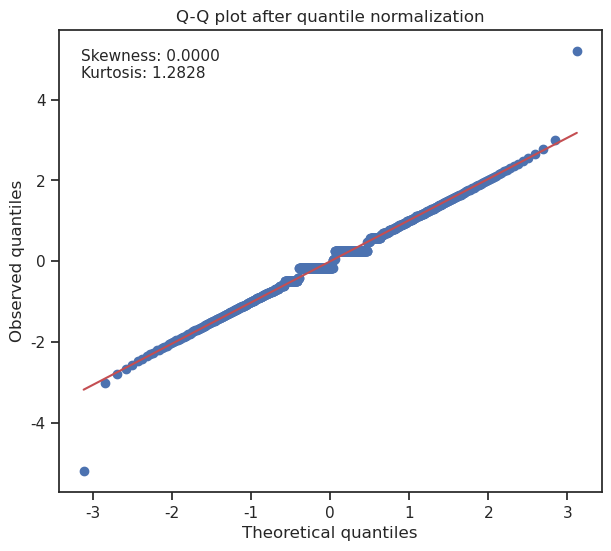

In [15]:
fig, ax = plt.subplots(figsize=(7, 6))
stats.probplot(z_scores, dist='norm', plot=ax)
ax.text(
    0.04,
    0.96,
    f'Skewness: {stats.skew(z_scores):.4f}\nKurtosis: {stats.kurtosis(z_scores):.4f}',
    transform=ax.transAxes,
    ha='left',
    va='top',
    fontsize=11,
)
ax.set_xlabel('Theoretical quantiles')
ax.set_ylabel('Observed quantiles')
ax.set_title('Q-Q plot after quantile normalization')
plt.show()

## 15. Export example outputs

In [15]:
summary = pd.concat([filter_summary, norm_summary, hit_summary, pd.Series({'nominal_p_threshold': P_THRESHOLD, 'nominal_z_threshold': Z_THRESHOLD, 'derived_delta_threshold': delta_threshold})])

summary_path = Path(f'{OUTPUT_PREFIX}_summary.csv')
hits_path = Path(f'{OUTPUT_PREFIX}_nominal_hits.csv')
filtered_path = Path(f'{OUTPUT_PREFIX}_filtered_for_statistics.csv')

summary.to_frame(name='value').to_csv(summary_path)
filtered_df.to_csv(filtered_path, index=False)
filtered_df.loc[filtered_df['pass_nominal_filter']].to_csv(hits_path, index=False)

print('Saved:', summary_path)
print('Saved:', filtered_path)
print('Saved:', hits_path)

Saved: gpsite_reproducible_example_summary.csv
Saved: gpsite_reproducible_example_filtered_for_statistics.csv
Saved: gpsite_reproducible_example_nominal_hits.csv


## 16. Reproducibility note

This notebook uses example data for demonstration. The same workflow can be applied to the full GPSite output table with the same column structure.